In [143]:
import numpy as np
import matplotlib.pyplot as plt

In [144]:
# EX 1
X = np.random.multivariate_normal(size=500, mean=[5, 10, 2], cov=[[3, 2, 2], [2, 10, 1], [2, 1, 2]])
print(X.shape)

(500, 3)


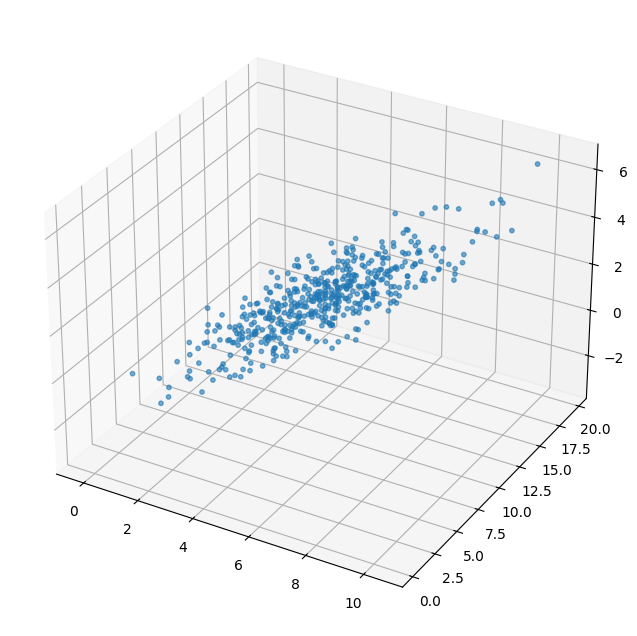

In [145]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], alpha=0.6, s=10)
plt.show()

In [146]:
mean_v = np.mean(X, axis=0)
X_centered = X - mean_v

In [147]:
cov_m = np.cov(X_centered, rowvar=False)

eigenval, eigenvec = np.linalg.eig(cov_m)
eigenval.shape, eigenvec.shape

((3,), (3, 3))

In [148]:
sorted_idx = np.argsort(eigenval)[::-1]
sorted_eigenvals = eigenval[sorted_idx]

In [149]:
# EX 2
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
from pyod.models.pca import PCA
from sklearn.preprocessing import StandardScaler

shuttle =  loadmat('shuttle.mat')
X, y = shuttle['X'], shuttle['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

In [150]:
cont_rate = len(np.where(y_train == 1)[0]) / len(y_train)
cont_rate

0.07332722273143905

In [151]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [152]:
pca_model = PCA(contamination=cont_rate)
pca_model.fit(X_train_scaled)

PCA(contamination=0.07332722273143905, copy=True, iterated_power='auto',
  n_components=None, n_selected_components=None, random_state=None,
  standardization=True, svd_solver='auto', tol=0.0, weighted=True,
  whiten=False)

In [153]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

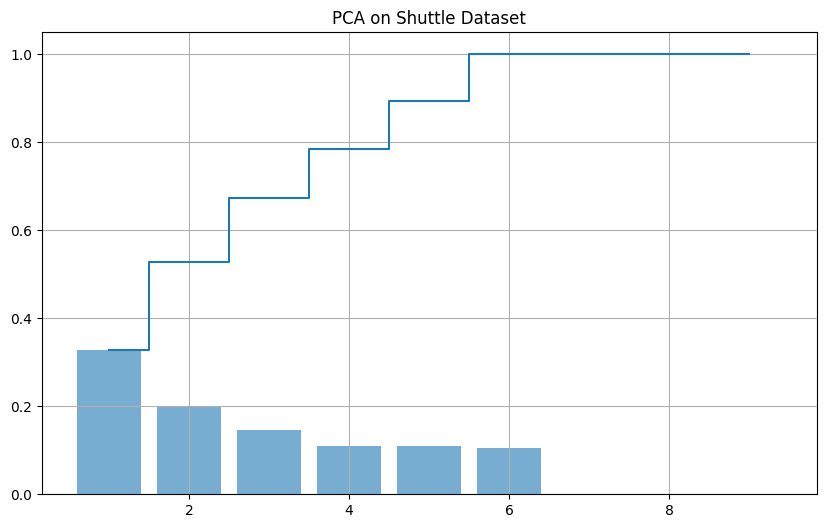

In [154]:
plt.figure(figsize=(10, 6))
x_labels = range(1, len(explained_variance) + 1)

plt.bar(x_labels, explained_variance, alpha=0.6)

plt.step(x_labels, cumulative_variance, where='mid')

plt.title('PCA on Shuttle Dataset')
plt.grid()
plt.show()

In [155]:
from sklearn.metrics import balanced_accuracy_score

y_train_pred_pca = pca_model.predict(X_train_scaled)
y_test_pred_pca = pca_model.predict(X_test_scaled)

bac_train_pca = balanced_accuracy_score(y_train, y_train_pred_pca)
bac_test_pca = balanced_accuracy_score(y_test, y_test_pred_pca)

print(f"PCA BAC Train: {bac_train_pca}")
print(f"PCA BAC Test:  {bac_test_pca}")

PCA BAC Train: 0.9718976673260797
PCA BAC Test:  0.9752102888709749


In [156]:
from pyod.models.kpca import KPCA

# using the full training set takes too long and uses tens of gigs of RAM
X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
    X_train_scaled, y_train, 
    train_size=1000,
    random_state=42, 
    stratify=y_train
)

kpca_Model = KPCA(contamination=cont_rate)
kpca_Model.fit(X_train_subset)

y_train_pred_kpca = kpca_Model.predict(X_train_scaled)
y_test_pred_kpca = kpca_Model.predict(X_test_scaled)

bac_train_kpca = balanced_accuracy_score(y_train, y_train_pred_kpca)
bac_test_kpca = balanced_accuracy_score(y_test, y_test_pred_kpca)

print(f"KPCA BAC Train: {bac_train_kpca}")
print(f"KPCA BAC Test:  {bac_test_kpca}")

KPCA BAC Train: 0.5214985850093417
KPCA BAC Test:  0.5239338396377976


In [157]:
# EX 3
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
from sklearn.preprocessing import MinMaxScaler

shuttle =  loadmat('shuttle.mat')
X, y = shuttle['X'], shuttle['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [158]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [172]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

class Autoencoder(keras.Model):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        self.encoder = keras.Sequential([
            layers.Dense(8, activation='relu'),
            layers.Dense(5, activation='relu'),
            layers.Dense(3, activation='relu')
        ], name="encoder")
        
        self.decoder = keras.Sequential([
            layers.Dense(5, activation='relu'),
            layers.Dense(8, activation='relu'),
            layers.Dense(input_dim, activation='sigmoid')
        ], name="decoder")

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_train_scaled.shape[1]
autoencoder = Autoencoder(input_dim)

In [173]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=1024,
    validation_data=(X_test_scaled, X_test_scaled),
    shuffle=True,
    verbose=1
)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0221 - val_loss: 0.0211
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0201 - val_loss: 0.0189
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0177 - val_loss: 0.0163
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0150 - val_loss: 0.0135
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0106
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0093 - val_loss: 0.0080
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0070 - val_loss: 0.0060
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

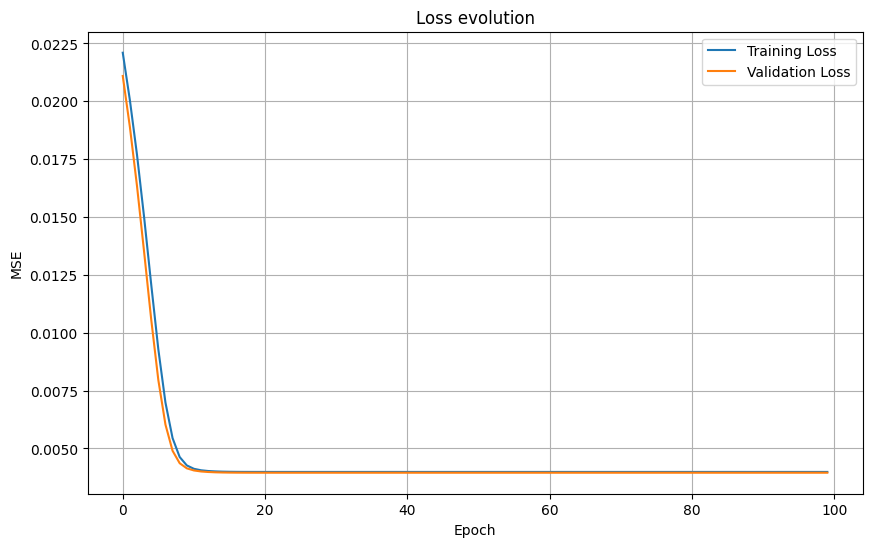

In [175]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss evolution')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [162]:
# EX 4
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

noise_factor = 0.35

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0, 1)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0, 1)



In [163]:
from tensorflow.keras import layers

class ConvolutionalAutoencoder(tf.keras.Model):
    def __init__(self):
        super(ConvolutionalAutoencoder, self).__init__()
        
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
    
            layers.Conv2D(filters=8, kernel_size=(3, 3), activation='relu', 
                          strides=2, padding='same'),
            layers.Conv2D(filters=4, kernel_size=(3, 3), activation='relu', 
                          strides=2, padding='same')
        ], name="encoder")

        self.decoder = tf.keras.Sequential([
            layers.Conv2DTranspose(filters=4, kernel_size=(3, 3), activation='relu', 
                                   strides=2, padding='same'),
            layers.Conv2DTranspose(filters=8, kernel_size=(3, 3), activation='relu', 
                                   strides=2, padding='same'),
            layers.Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', 
                          padding='same')
        ], name="decoder")

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [164]:
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))
x_test_noisy = x_test_noisy.numpy().reshape((-1, 28, 28, 1))

autoencoder = ConvolutionalAutoencoder()

autoencoder.compile(optimizer='adam', loss='mse')

training = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, x_test),
    shuffle=True
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0375 - val_loss: 0.0047
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0021 - val_loss: 0.0020


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


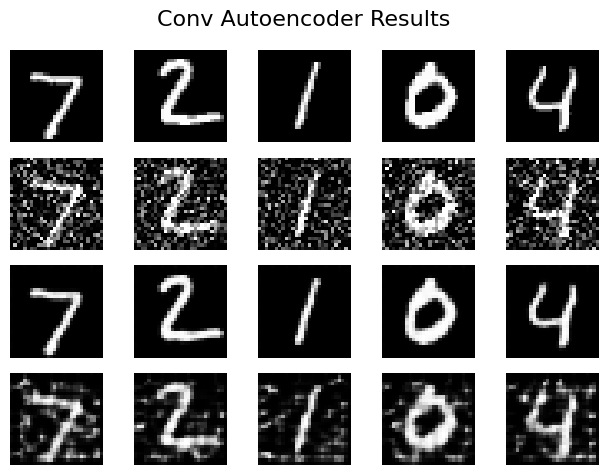

In [165]:
import matplotlib.pyplot as plt

n = 5
indices = range(n)
original_images = x_test[indices]
noisy_images = x_test_noisy[indices]

reconstructed_original = autoencoder.predict(original_images)

reconstructed_noisy = autoencoder.predict(noisy_images)


fig, axes = plt.subplots(4, 5)

for i in range(n):
    axes[0][i].imshow(original_images[i].reshape(28, 28), cmap='gray')
    axes[0][i].axis('off')

    
for i in range(n):
    axes[1][i].imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    axes[1][i].axis('off')

for i in range(n):
    axes[2][i].imshow(reconstructed_original[i].reshape(28, 28), cmap='gray')
    axes[2][i].axis('off')

    
for i in range(n):
    axes[3][i].imshow(reconstructed_noisy[i].reshape(28, 28), cmap='gray')
    axes[3][i].axis('off')

    
plt.suptitle("Conv Autoencoder Results", fontsize=16)
plt.tight_layout()
plt.show()

In [168]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

noise_factor = 0.35

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, 0, 1)
x_test_noisy = tf.clip_by_value(x_test_noisy, 0, 1)
denoising_autoencoder = ConvolutionalAutoencoder()

denoising_autoencoder.compile(optimizer='adam', loss='mse')

history_denoise = denoising_autoencoder.fit(
    x_train_noisy,   
    x_train,         
    epochs=10,
    batch_size=64,
    validation_data=(x_test_noisy, x_test),
    shuffle=True
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0395 - val_loss: 0.0116
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0105 - val_loss: 0.0098
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0097 - val_loss: 0.0092
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0093 - val_loss: 0.0089
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0090 - val_loss: 0.0088
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0089 - val_loss: 0.0087
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0087 - val_loss: 0.0085


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


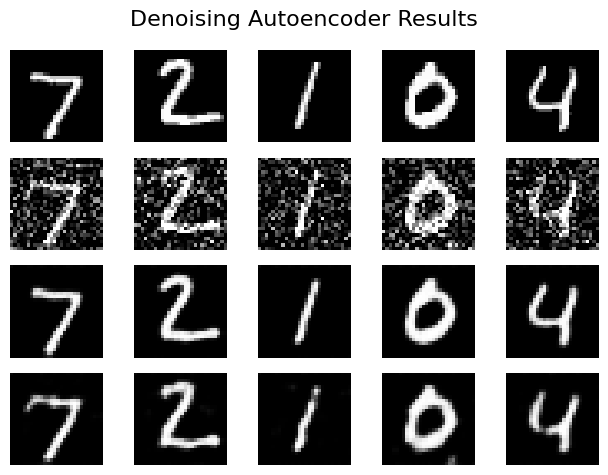

In [170]:
n = 5
indices = range(n)
original_images = x_test[indices]
noisy_images = x_test_noisy.numpy()[indices]

reconstructed_original = denoising_autoencoder.predict(original_images)

reconstructed_noisy = denoising_autoencoder.predict(noisy_images)

fig, axes = plt.subplots(4, 5)

for i in range(n):
    axes[0][i].imshow(original_images[i].reshape(28, 28), cmap='gray')
    axes[0][i].axis('off')

    
for i in range(n):
    axes[1][i].imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    axes[1][i].axis('off')

for i in range(n):
    axes[2][i].imshow(reconstructed_original[i].reshape(28, 28), cmap='gray')
    axes[2][i].axis('off')

    
for i in range(n):
    axes[3][i].imshow(reconstructed_noisy[i].reshape(28, 28), cmap='gray')
    axes[3][i].axis('off')

    
plt.suptitle("Denoising Autoencoder Results", fontsize=16)
plt.tight_layout()
plt.show()